# Wine Quality Dataset: Clasificación y Regresión de Calidad de Vino

En este notebook predeciremos la “calidad” del vino tanto como variable continua (regresión) como una categoría (clasificación), usando regresión logística, lineal y Random Forest.

## Conceptos principales
- **Clasificación binaria**: Cuando transformamos la calidad en “alta” o “baja”
- **Regresión**: Predicción directa del score de calidad
- **Datos desbalanceados**: Cuando tienes muchas más muestras de una clase que de otra


In [1]:
# Importar librerías y cargar datos
import pandas as pd  # Para manejar tablas de datos
import matplotlib.pyplot as plt  # Para hacer gráficos
import seaborn as sns  # Para gráficos estadísticos

# Cargamos el archivo CSV con los datos de vinos
df = pd.read_csv('WineQT.csv')

# Mostramos las primeras filas para ver cómo son los datos
print(df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

### Observación
Revisa la estructura del dataset y piensa:
- ¿Qué variables podrías usar para predecir si un vino es bueno?


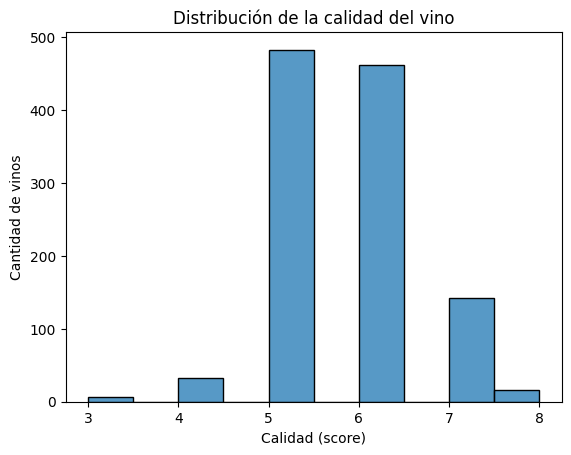

In [2]:
# Distribución de la variable 'quality'
# Esto nos ayuda a ver cuántos vinos hay de cada calidad
sns.histplot(df['quality'], bins=10)
plt.title('Distribución de la calidad del vino')
plt.xlabel('Calidad (score)')
plt.ylabel('Cantidad de vinos')
plt.show()

# EXPLICACIÓN:
# El gráfico muestra cuántos vinos hay para cada puntuación de calidad.
# Si ves que la mayoría de vinos tienen una calidad similar, significa que los datos están desbalanceados.
# Esto puede afectar a los modelos, porque aprenderán mejor sobre la clase más frecuente.

**Pregunta para reflexionar:**  
- ¿La calidad está bien balanceada o predominan algunos valores?


In [3]:
# Transformación a clasificación binaria de calidad
# Creamos una nueva columna: 1 si la calidad es 7 o más (vino bueno), 0 si es menor (vino normal)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Vemos cuántos vinos buenos y normales hay
print(df['quality_label'].value_counts())


quality_label
0    984
1    159
Name: count, dtype: int64


**Clasificación binaria:**  
Nos ayuda a responder preguntas tipo "¿Este vino es bueno o malo?" en vez de predecir el score exacto.


In [4]:
# Split en entrenamiento/test para clasificación
# Separamos los datos en dos grupos: uno para entrenar el modelo y otro para probarlo
from sklearn.model_selection import train_test_split

# X son las variables que usaremos para predecir, y es la respuesta (vino bueno o no)
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

# 70% para entrenar, 30% para probar. random_state=42 hace que siempre salga igual.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Accuracy: 0.892128279883382
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       298
           1       0.68      0.33      0.45        45

    accuracy                           0.89       343
   macro avg       0.79      0.65      0.69       343
weighted avg       0.88      0.89      0.88       343



C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


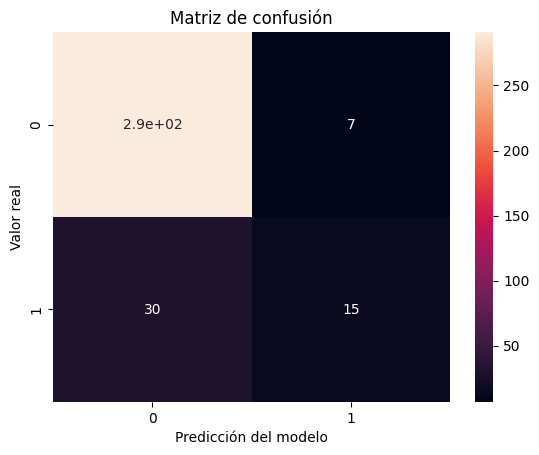

In [5]:
# Regresión logística: predicción binaria
# Este modelo intenta predecir si el vino es bueno (1) o no (0)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Creamos el modelo y lo entrenamos con los datos de entrenamiento
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Hacemos predicciones con los datos de prueba
y_pred = logreg.predict(X_test)

# Mostramos qué porcentaje acierta el modelo
print('Accuracy:', accuracy_score(y_test, y_pred))

# Mostramos un reporte más detallado (precisión, recall, etc.)
print('Reporte de clasificación:\n', classification_report(y_test, y_pred))

# Mostramos la matriz de confusión: cuántos aciertos y errores
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title('Matriz de confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

# EXPLICACIÓN:
# La matriz de confusión te muestra cuántos vinos fueron clasificados correctamente y cuántos no.
# - Diagonal principal: aciertos (predicción igual a realidad).
# - Fuera de la diagonal: errores (falsos positivos o negativos).
# Así puedes ver si el modelo confunde más los vinos buenos o los normales.

**¿Cómo se evalúa un modelo de clasificación?**  
- Accuracy: % de aciertos totales
- Matriz de confusión: muestra falsos positivos/negativos y verdaderos positivos/negativos.

### ¿Cómo interpretar la matriz de confusión?

- **Fila 0 (Valor real = 0):** Vinos que en realidad NO son buenos.
  - **Columna 0:** El modelo predijo correctamente que NO son buenos (aciertos, llamados "verdaderos negativos").
  - **Columna 1:** El modelo se equivocó y dijo que eran buenos (errores, llamados "falsos positivos").

- **Fila 1 (Valor real = 1):** Vinos que en realidad SÍ son buenos.
  - **Columna 0:** El modelo se equivocó y dijo que NO eran buenos (errores, llamados "falsos negativos").
  - **Columna 1:** El modelo acertó y dijo que SÍ eran buenos (aciertos, llamados "verdaderos positivos").

En resumen:
- **Diagonal principal:** Aciertos (predicción igual a realidad).
- **Fuera de la diagonal:** Errores.

Esto te ayuda a ver si el modelo confunde más los vinos buenos o los normales y si comete más errores de un tipo que de otro.

El modelo tiene muy buen desempeño al predecir la clase 0, pero falla en muchos casos de la clase 1.
Esto puede indicar:

Desbalance de clases (muchos más 0 que 1).

O que el modelo no está captando bien las características de la clase 1.

RMSE: 0.6226246066972996
F1-score: 0.44776119402985076


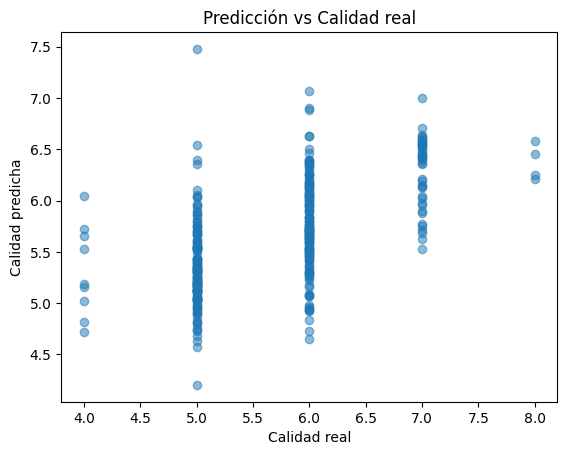

In [9]:
# Regresión lineal: predicción del score de calidad
# Aquí intentamos predecir el valor exacto de la calidad (no solo bueno/malo)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

y_reg = df['quality']  # La variable que queremos predecir
X_reg = df.drop(columns=['quality', 'quality_label'])  # Usamos las mismas variables que antes

# Separamos en entrenamiento y test
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Creamos y entrenamos el modelo de regresión lineal
reg = LinearRegression()
reg.fit(Xr_train, yr_train)

# Hacemos predicciones
yr_pred = reg.predict(Xr_test)

# Calculamos el error cuadrático medio (RMSE)
import numpy as np
print('RMSE:', np.sqrt(mean_squared_error(yr_test, yr_pred)))
# Vamos a calcular el F1-score y analizar el posible desbalance de clase
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)   
print('F1-score:', f1)
# EXPLICACIÓN:
# El RMSE (Root Mean Squared Error) indica cuánto se equivoca el modelo al predecir la calidad.
# Un valor más bajo significa que el modelo predice mejor.
# Si quieres visualizar la relación entre predicción y realidad, puedes hacer un scatterplot así:
plt.scatter(yr_test, yr_pred, alpha=0.5)
plt.xlabel('Calidad real')
plt.ylabel('Calidad predicha')
plt.title('Predicción vs Calidad real')
plt.show()
# Si los puntos están cerca de la línea diagonal, el modelo predice bien.

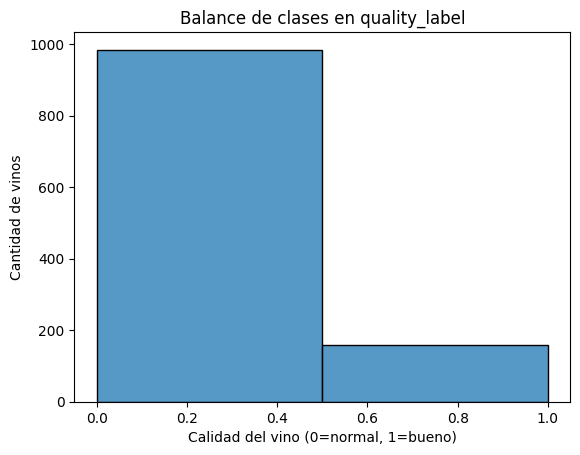

In [10]:
# Análisis del balance de clases
import matplotlib.pyplot as plt
sns.histplot(df['quality_label'], bins=2)
plt.title('Balance de clases en quality_label')
plt.xlabel('Calidad del vino (0=normal, 1=bueno)')
plt.ylabel('Cantidad de vinos')
plt.show()

Solo 13% de los datos son de la clase 1,
mientras que 87% son de la clase 0 → hay fuerte desbalance.

## Recomendaciones:

* Aplicar re-muestreo:

    - Oversampling de la clase 1 (por ejemplo con SMOTE).

    - O undersampling de la clase 0.

* Usar métricas más robustas al desbalance, como:

    - ROC-AUC, Precision-Recall AUC, o Balanced Accuracy.

* Ajustar el umbral de decisión del modelo para mejorar el recall.

    - Considerar ponderar las clases (class weights) durante el entrenamiento.

**¿Por qué puede ser útil la regresión aquí?**  
Permite anticipar la puntuación exacta y analizar si algunas propiedades químicas influyen más en la calidad que otras.


In [11]:
# Random Forest para clasificación
# Un Random Forest es como un "equipo" de muchos árboles de decisión.
# Cada árbol hace una predicción y el modelo final toma el voto de la mayoría.
# Esto suele dar mejores resultados que un solo modelo simple.

from sklearn.ensemble import RandomForestClassifier

# Creamos el modelo y lo entrenamos
clf_rf = RandomForestClassifier()
clf_rf.fit(X_train, y_train)

# Hacemos predicciones con los datos de test
y_pred_rf = clf_rf.predict(X_test)

# Mostramos el porcentaje de aciertos
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))

# Puedes ver qué variables son más importantes para el modelo así:
importances = clf_rf.feature_importances_
features = X.columns
import numpy as np
indices = np.argsort(importances)[::-1]
print('Importancia de variables (de mayor a menor):')
for f in range(len(features)):
    print(f'{features[indices[f]]}: {importances[indices[f]]:.3f}')

# EXPLICACIÓN:
# El Random Forest también te permite ver qué variables (características) son más importantes para predecir la calidad.
# Así puedes saber, por ejemplo, si el alcohol o la acidez influyen más en que un vino sea bueno.

Random Forest Accuracy: 0.9183673469387755
Importancia de variables (de mayor a menor):
alcohol: 0.140
sulphates: 0.122
volatile acidity: 0.114
citric acid: 0.093
density: 0.083
total sulfur dioxide: 0.071
chlorides: 0.071
fixed acidity: 0.070
Id: 0.066
pH: 0.062
residual sugar: 0.055
free sulfur dioxide: 0.052


#### Espacio para tu análisis:
- ¿Mejoró la precisión con el Random Forest?
- ¿Qué variables parecen clave para determinar la calidad? Busca la importancia de variables (`feature_importances_`).
